# Chapter 06
 Machine Learning for Business Analytics<br>
Concepts, Techniques, and Applications in Python<br>
by Galit Shmueli, Peter C. Bruce, Peter Gedeck, Nitin R. Patel

Publisher: Wiley; 2nd edition (2024) <br>
<!-- ISBN-13: 978-3031075650 -->

(c) 2024 Galit Shmueli, Peter C. Bruce, Peter Gedeck, Nitin R. Patel

The code needs to be executed in sequence.

Python packages and Python itself change over time. This can cause warnings or errors.
"Warnings" are for information only and can usually be ignored.
"Errors" will stop execution and need to be fixed in order to get results.

If you come across an issue with the code, please follow these steps

- Check the repository (https://gedeck.github.io/sdsa-code-solutions/) to see if the code has been upgraded. This might solve the problem.
- Report the problem using the issue tracker at https://github.com/gedeck/sdsa-code-solutions/issues
- Paste the error message into Google and see if someone else already found a solution

##Import libraries
This cell imports the necessary Python libraries and install the mlba package to access datasets and analysis tools.

In [25]:
import matplotlib.pyplot as plt
!pip install mlba
import mlba
import numpy as np
import pandas as pd
import statsmodels.formula.api as sm
from mlxtend.feature_selection import ExhaustiveFeatureSelector, SequentialFeatureSelector
from sklearn.linear_model import BayesianRidge, Lasso, LassoCV, LinearRegression, Ridge, RidgeCV
from sklearn.model_selection import cross_validate, train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
%matplotlib inline

##Load data, prepare predictors, fit linear regression, and print coefficients and training performance  
The Toyota Corolla dataset is loaded and reduced to the first 1000 rows. A set of predictors is chosen, and the categorical variable `Fuel_Type` is converted to dummy variables using `pd.get_dummies` with `drop_first=True` to avoid multicollinearity. The data is split into training (60%) and holdout (40%) sets. A linear regression model is fitted on the training data, and the coefficients are printed, followed by regression performance metrics on the training set.  

**Interpretation of coefficients (as shown in Table 6.3 of the textbook):**  
- **Age_08_04** (age in months): coefficient –130.79 → each additional month of age reduces the price by about $131, holding other factors constant.  
- **KM** (kilometers): coefficient –0.0183 → each additional kilometer driven reduces the price by about 1.8 cents; for 10,000 km, that’s about $183.  
- **HP** (horsepower): coefficient 64.83 → each extra horsepower increases price by about $65.  
- **Met_Color** (metallic color): coefficient 54.28 → metallic color adds about $54 to the price.  
- **Automatic** (automatic transmission): coefficient 298.01 → automatic transmission adds about $298.  
- **CC** (engine size in cc): coefficient –4.25 → **counterintuitively**, larger engine size decreases price by about $4 per cc. This could be because larger engines are associated with older models or higher fuel consumption, which may be undesirable in the used car market.  
- **Doors**: coefficient –25.89 → each additional door reduces price by about $26; perhaps more doors indicate a less sporty model or a family car that depreciates faster.  
- **Quarterly_Tax**: coefficient 18.01 → higher quarterly tax adds $18 per unit; likely reflects a more expensive car to begin with.  
- **Weight**: coefficient 15.55 → each additional kg adds about $15.50; heavier cars may be perceived as safer or more luxurious.  
- **Fuel_Type_Diesel** (dummy, baseline = CNG): coefficient 3875.78 → diesel adds about $3,876 compared to CNG.  
- **Fuel_Type_Petrol** (dummy, baseline = CNG): coefficient 2897.53 → petrol adds about $2,898 compared to CNG.  

**Training performance:** RMSE ≈ 1340, MAE ≈ 988, MAPE ≈ 8.8%.

In [26]:
# reduce data frame to the top 1000 rows and select columns for regression analysis
car_df = mlba.load_data('ToyotaCorolla.csv')
car_df = car_df.iloc[0:1000]

predictors = ['Age_08_04', 'KM', 'Fuel_Type', 'HP', 'Met_Color', 'Automatic', 'CC',
              'Doors', 'Quarterly_Tax', 'Weight']
outcome = 'Price'

# partition data
X = pd.get_dummies(car_df[predictors], drop_first=True)
y = car_df[outcome]
train_X, holdout_X, train_y, holdout_y = train_test_split(X, y, test_size=0.4,
                                                    random_state=314)

car_lm = LinearRegression()
car_lm.fit(train_X, train_y)

# print coefficients
print(pd.DataFrame({'Predictor': X.columns, 'coefficient': car_lm.coef_}))

# print performance measures (training data)
mlba.regressionSummary(y_true=train_y, y_pred=car_lm.predict(train_X))

           Predictor  coefficient
0          Age_08_04  -130.792830
1                 KM    -0.018302
2                 HP    64.834495
3          Met_Color    54.282338
4          Automatic   298.009711
5                 CC    -4.251357
6              Doors   -25.888900
7      Quarterly_Tax    18.013228
8             Weight    15.547273
9   Fuel_Type_Diesel  3875.777969
10  Fuel_Type_Petrol  2897.532504

Regression statistics

Mean Error (ME) : -0.0000
Root Mean Squared Error (RMSE) : 1340.1580
Mean Absolute Error (MAE) : 987.7296
Mean Percentage Error (MPE) : -0.9911
Mean Absolute Percentage Error (MAPE) : 8.8094


##Predictions on holdout set and performance evaluation  
The fitted model is used to predict prices on the holdout set. The first 20 rows of predictions, actual values, and residuals are printed, followed by overall regression statistics on the holdout data.  

**Holdout performance:** ME ≈ –1.36 (very small bias), RMSE ≈ 1355, MAE ≈ 1028, MAPE ≈ 9.06%. These metrics are slightly worse than on the training set, indicating a small degree of overfitting.

In [27]:
# Use predict() to make predictions on a new set
car_lm_pred = car_lm.predict(holdout_X)

result = pd.DataFrame({'Predicted': car_lm_pred, 'Actual': holdout_y,
                       'Residual': holdout_y - car_lm_pred})
print(result.head(20))

# print performance measures (holdout data)
mlba.regressionSummary(y_true=holdout_y, y_pred=car_lm_pred)

        Predicted  Actual     Residual
764  10073.017338   10950   876.982662
277  12649.704215   11495 -1154.704215
515  10317.854192   10750   432.145808
305  13075.699963   11895 -1180.699963
108  17210.881336   17950   739.118664
392  10627.038857    9950  -677.038857
905   9179.342231    9950   770.657769
507  11015.919573   11500   484.080427
789   9880.554635    8950  -930.554635
260  12124.410668   11950  -174.410668
69   16177.924091   15950  -227.924091
60   16429.726963   14950 -1479.726963
744   7987.909413    7450  -537.909413
584  10731.467539   10500  -231.467539
223  11392.715402   14950  3557.284598
104  19597.277288   19450  -147.277288
335  13441.801213   12500  -941.801213
463  11886.513474    8750 -3136.513474
224  13559.243997   12450 -1109.243997
269  12608.507012   10950 -1658.507012

Regression statistics

Mean Error (ME) : -1.3621
Root Mean Squared Error (RMSE) : 1355.0409
Mean Absolute Error (MAE) : 1028.0884
Mean Percentage Error (MPE) : -1.2047
Mean Absolut

##Histogram of residuals on holdout set  
A histogram of the residuals (actual – predicted) for the holdout set is plotted with 25 bins. This visualisation helps check the normality and spread of errors. The residuals appear roughly centered around zero, though there may be some skewness or outliers.

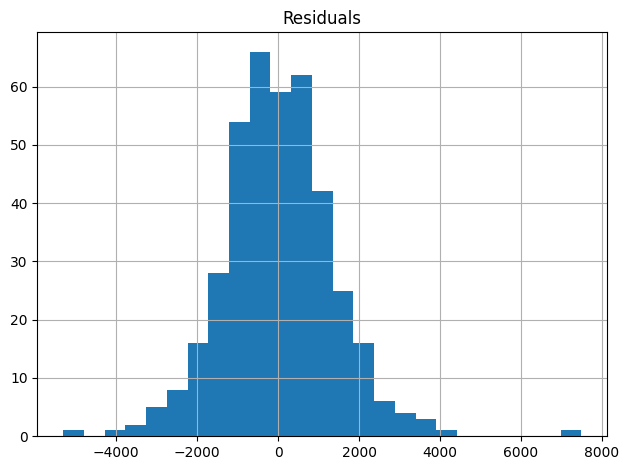

In [28]:
car_lm_pred = car_lm.predict(holdout_X)
all_residuals = holdout_y - car_lm_pred

pd.DataFrame({'Residuals': all_residuals}).hist(bins=25)
plt.tight_layout()
plt.show()

##Percentage of residuals within a given interval  
This code calculates the fraction of residuals that lie between –1406 and 1406 (approximately 75% of the data). The result (0.7425) indicates that about 74.25% of the holdout predictions are within that range, which is close to the expected 75% if residuals were normally distributed.

In [29]:
# Determine the percentage of datapoints with a residual
# in [-1406, 1406] = approx. 75\% of the data
print(len(all_residuals[(all_residuals > -1406) & (all_residuals < 1406)]) /
len(all_residuals))

0.7425


##Cross‑validation on the training set  
Five‑fold cross‑validation is performed on the training data using the same linear regression model. The scoring metrics are negative RMSE and negative MAE (scikit‑learn convention: higher is better, so negative values are used). The mean of the absolute values (RMSE and MAE) across folds is printed.  

**Cross‑validation results:** CV‑RMSE ≈ 1514.51, CV‑MAE ≈ 1052.89. These are slightly higher than the training errors, confirming some overfitting but still reasonable.

In [30]:
from sklearn.model_selection import cross_validate

model = LinearRegression()

scoring = {'neg_RMSE': 'neg_root_mean_squared_error',
           'neg_MAE': 'neg_mean_absolute_error'}
scores = cross_validate(model, train_X, train_y, cv=5, scoring=scoring)

print(f"CV-RMSE = {- scores['test_neg_RMSE'].mean():.2f}")
print(f"CV-MAE = {- scores['test_neg_MAE'].mean():.2f}")

CV-RMSE = 1514.51
CV-MAE = 1052.89


##Store cross‑validation results in a dictionary  
This cell simply stores the average RMSE and MAE from cross‑validation into a dictionary.

In [31]:
cv_results = {'RMSE': - scores['test_neg_RMSE'].mean(),
              'MAE': - scores['test_neg_MAE'].mean()}